In [14]:
import sys
import os
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_style('darkgrid')

from src.simulation_generation import load_simulation
from src.utils import simulate_target_weight_portfolio

## ACF plot for thesis

In [165]:
import yfinance as yf

rr = yf.download("^GSPC", '2014-01-01', "2018-01-01")

[*********************100%***********************]  1 of 1 completed


In [167]:
rr = rr.Close
rr = np.log(rr) - np.log(rr.shift(1))

In [168]:
rr.dropna(inplace=True)

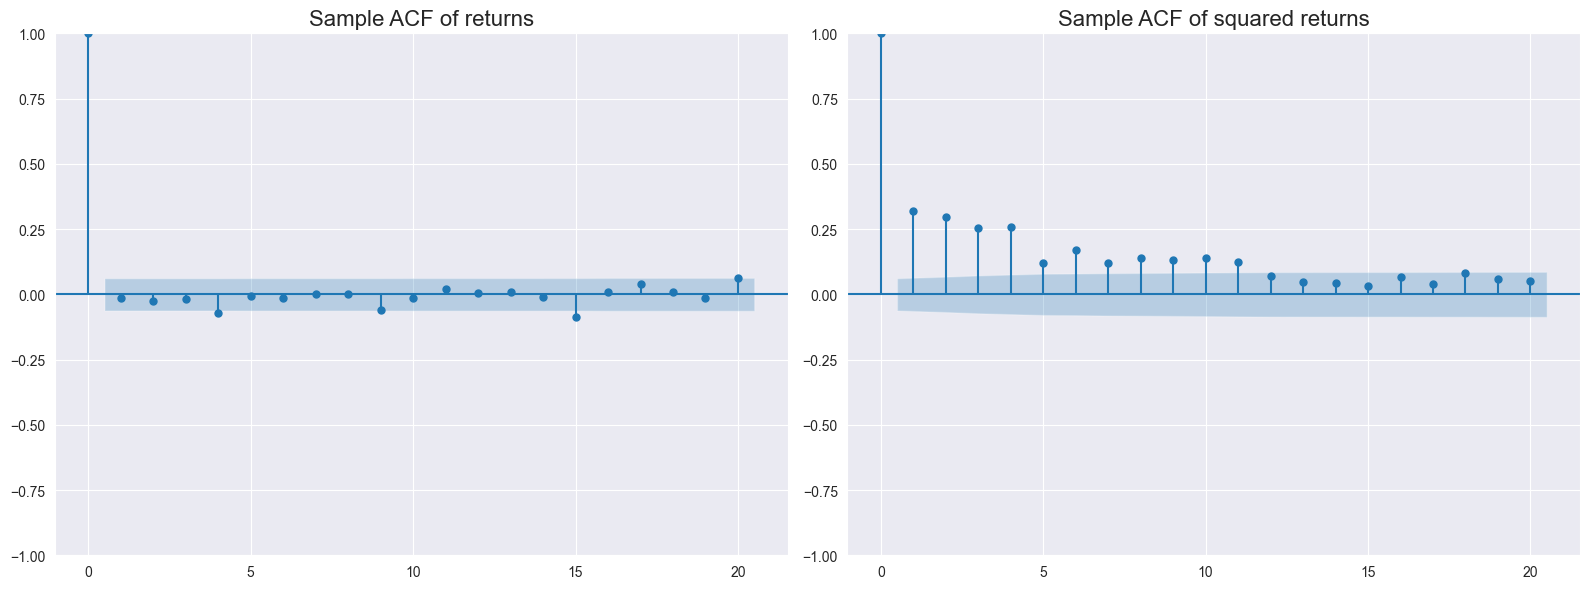

In [278]:
#plot sample acf
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2,figsize=(16, 6))

from statsmodels.graphics.tsaplots import plot_acf
_ = plot_acf(rr, lags=20, ax=ax[0])
_ = plot_acf(rr**2, lags=20, ax=ax[1])

ax[0].set_title("Sample ACF of returns", fontsize=16)
ax[1].set_title("Sample ACF of squared returns", fontsize=16)

fig.tight_layout()
fig.savefig(project_root / "results/returns_acf.pdf")

## Analysis start here

In [5]:
import yaml
from joblib import load, dump

# load configuration
with open(project_root / 'configs' / 'test_config.yaml', 'r') as f:
    config = yaml.safe_load(f)

n_simulations = config['n_simulations']
n_steps = config['n_steps']
N = config['N']
T = config['T']
K = config['K']

trade_cost = config['trade_cost']
market_path = project_root / config['market_path']
save_path = project_root / config['save_path']

market = load(market_path)
rf = market.rf

In [6]:
market_sims_full = np.zeros((n_simulations, n_steps+1))
eq_sims_full = np.zeros((n_simulations, n_steps+1, N+1))

x_init = [100] + [0 for _ in range(N)]

for i in range(n_simulations):
    actual_traj, market_return, _ = load_simulation(project_root / "datasets/test", i)
    
    market_sims_full[i] = np.exp(np.concat([[0], market_return * market.betas.mean()])).cumprod() * 100
    eq_sims_full[i] = simulate_target_weight_portfolio(x_init, [0] + [1/N for _ in range(N)], rf, pd.DataFrame(actual_traj.T), trading_cost=trade_cost)

In [7]:
MPC_sims_full = load(save_path / f"{config['name']}_sims.joblib")

In [8]:
market_sims = pd.DataFrame(market_sims_full)
MPC_sims = pd.DataFrame(MPC_sims_full.sum(axis=2))
eq_sims = pd.DataFrame(eq_sims_full.sum(axis=2))

In [9]:
import src.portfolio_analysis
from importlib import reload
reload(src.portfolio_analysis)

<module 'src.portfolio_analysis' from 'C:\\Users\\lovas\\Desktop\\Szakdoga\\code\\src\\portfolio_analysis.py'>

In [10]:
from src.portfolio_analysis import plot_simulations, compute_returns, compute_metrics

In [24]:
MPC_sims.columns

RangeIndex(start=0, stop=21, step=1)

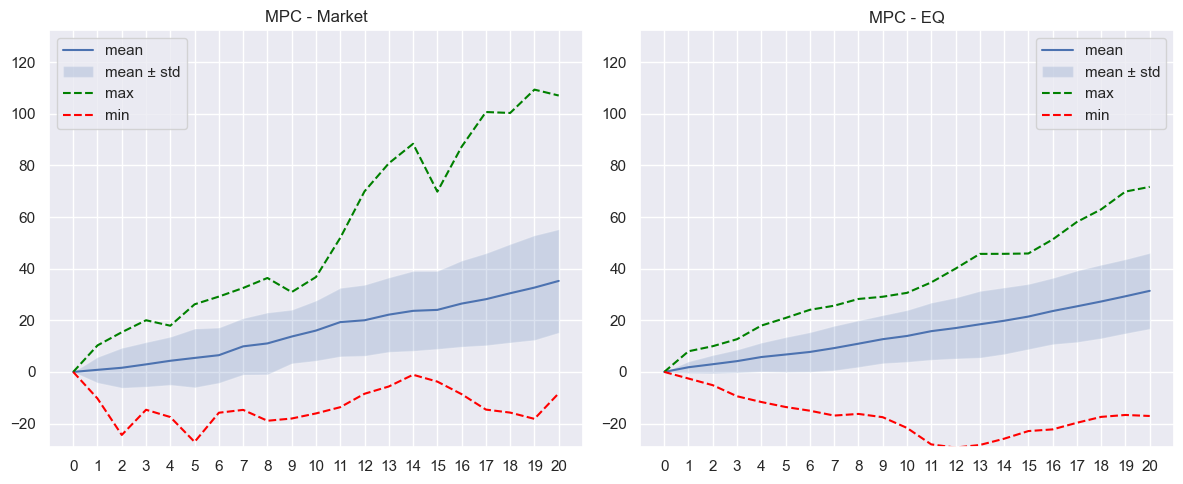

In [44]:
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(1,2, figsize=(12,5))

plot_simulations([MPC_sims - market_sims, MPC_sims - eq_sims], labels=["MPC - Market", 'MPC - EQ'], ax=ax)

for aa in ax:
    aa.set_xticks(range(0, n_steps + 1))

fig.tight_layout()
fig.savefig(project_root / "results/figures/comparison_diff.pdf")

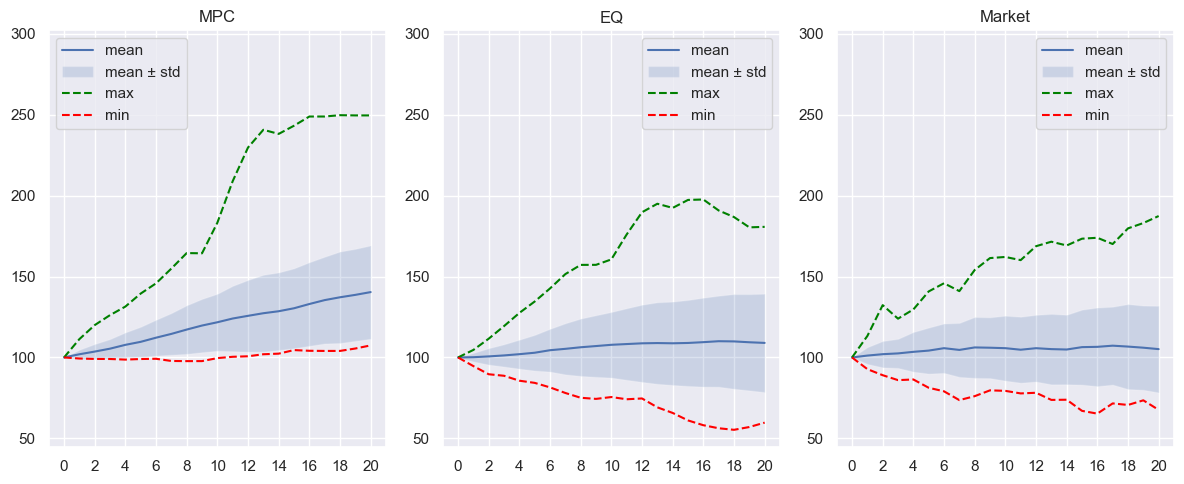

In [45]:
fig, ax = plt.subplots(1,3, figsize=(12,5))

plot_simulations([MPC_sims, eq_sims, market_sims], labels=['MPC', 'EQ', 'Market'], ax=ax)

for aa in ax:
    aa.set_xticks(range(0, n_steps + 1, 2))

fig.tight_layout()
fig.savefig(project_root / "results/figures/comparison.pdf")

In [48]:
returns = compute_returns([MPC_sims, eq_sims, market_sims], names=['MPC', 'EQ', 'Market'])

In [40]:
(returns['MPC'] < -0.01).sum().sum() # No exceeded 1% loss in any simulation for MPC

np.int64(22)

In [50]:
def multi_level_metric(df):
    # df = your original dataframe
    # Example: rows are metrics, columns are misspec levels

    # --------------------------------------------
    # STEP 1: convert row labels into MultiIndex
    # --------------------------------------------

    def split_metric(row_name):
        """
        Convert:
        'mean of sharpe ratios'
        -> ('sharpe ratios', 'mean')

        'ci_low of mean returns'
        -> ('mean returns', 'ci_low')
        """

        stat_prefixes = [
            "mean of ",
            "std of ",
            "se of ",
            "ci_low of ",
            "ci high of ",
            "ci_high of "
        ]

        for prefix in stat_prefixes:
            if row_name.startswith(prefix):
                metric = row_name.replace(prefix, "")
                stat = prefix.replace(" of ", "").strip()

                # normalize naming
                stat = (
                    stat.replace("ci high", "ci_high")
                        .replace("ci low", "ci_low")
                )

                return metric, stat

        return row_name, "value"


    # Build MultiIndex tuples
    tuples = [split_metric(idx) for idx in df.index]

    # Assign MultiIndex
    df_multi = df.copy()
    df_multi.index = pd.MultiIndex.from_tuples(
        tuples,
        names=["metric", "stat"]
    )

    # Optional: sort nicely
    stat_order = ["mean", "std", "se", "ci_low", "ci_high"]

    df_multi = (
        df_multi.reset_index()
        .assign(
            stat=lambda x: pd.Categorical(
                x["stat"],
                categories=stat_order,
                ordered=True
            )
        )
        .sort_values(["metric", "stat"])
        .set_index(["metric", "stat"])
    )

    return df_multi

In [56]:
metrics = compute_metrics(returns, rf)
metrics = multi_level_metric(metrics)
metrics.loc['sharpe ratios']

,MPC,EQ,Market
stat,,,
mean,0.673512,0.127932,0.044423
std,0.262163,0.539360,0.231945
se,0.037075,0.076277,0.032802
ci_low,0.599006,-0.025353,-0.021495
ci_high,0.748018,0.281216,0.110341


In [59]:
metrics.index.levels[0]

Index(['95% CVaR', '95% VaR', 'average drawdowns', 'max drawdowns',
       'mean returns', 'sharpe ratios', 'sortino ratios'],
      dtype='str', name='metric')

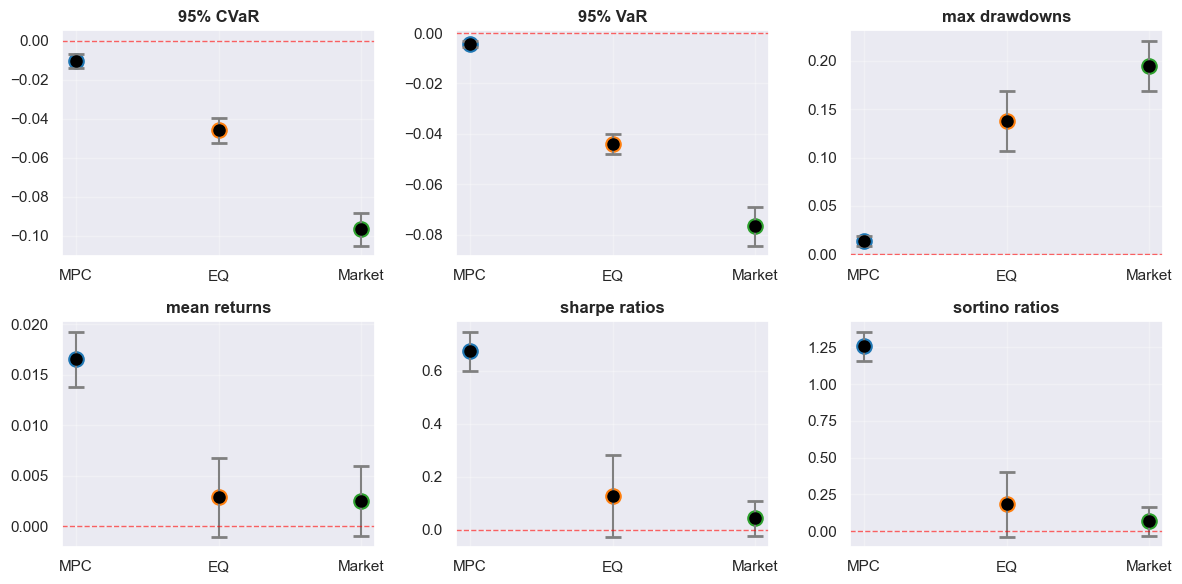

In [71]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
portfolios = ['MPC', 'EQ', 'Market']

metrics_to_plot = metrics.index.levels[0].drop("average drawdowns")

for ax, metric in zip(axes, metrics_to_plot):

    vals = metrics.loc[metric]

    means = np.array(vals.loc['mean'])
    lows = np.array(vals.loc['ci_low'])
    highs = np.array(vals.loc['ci_high'])

    yerr = [means - lows, highs - means]

    ax.errorbar(
        portfolios,
        means,
        yerr=yerr,
        fmt='o',
        capsize=6,
        capthick=2,
        markersize=8,
        color='black',
        ecolor='gray'
    )

    for i, m in enumerate(means):
        ax.scatter(portfolios[i], m, s=120, color=colors[i])

    ax.axhline(0, linestyle='--', linewidth=1, color='red', alpha=0.6)

    ax.set_title(metric, fontsize=12, weight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(project_root / "results/figures/base_metrics_comparison.pdf")
plt.show()

## Allocation

In [81]:
sns.set_theme()

<Axes: >

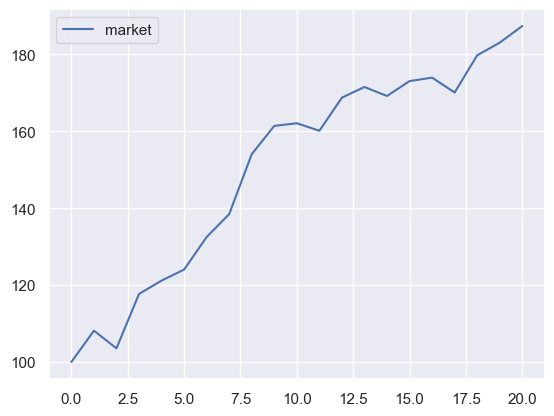

In [102]:
market_sims.iloc[0].plot(label='market', legend=True)

In [107]:
sim_num = 0 # Sim 0 for market uptrend, 2 for downtrend towards end, 3 spike in the middle

df = pd.DataFrame(MPC_sims_full[sim_num])
eq_df = pd.DataFrame(eq_sims_full[sim_num])

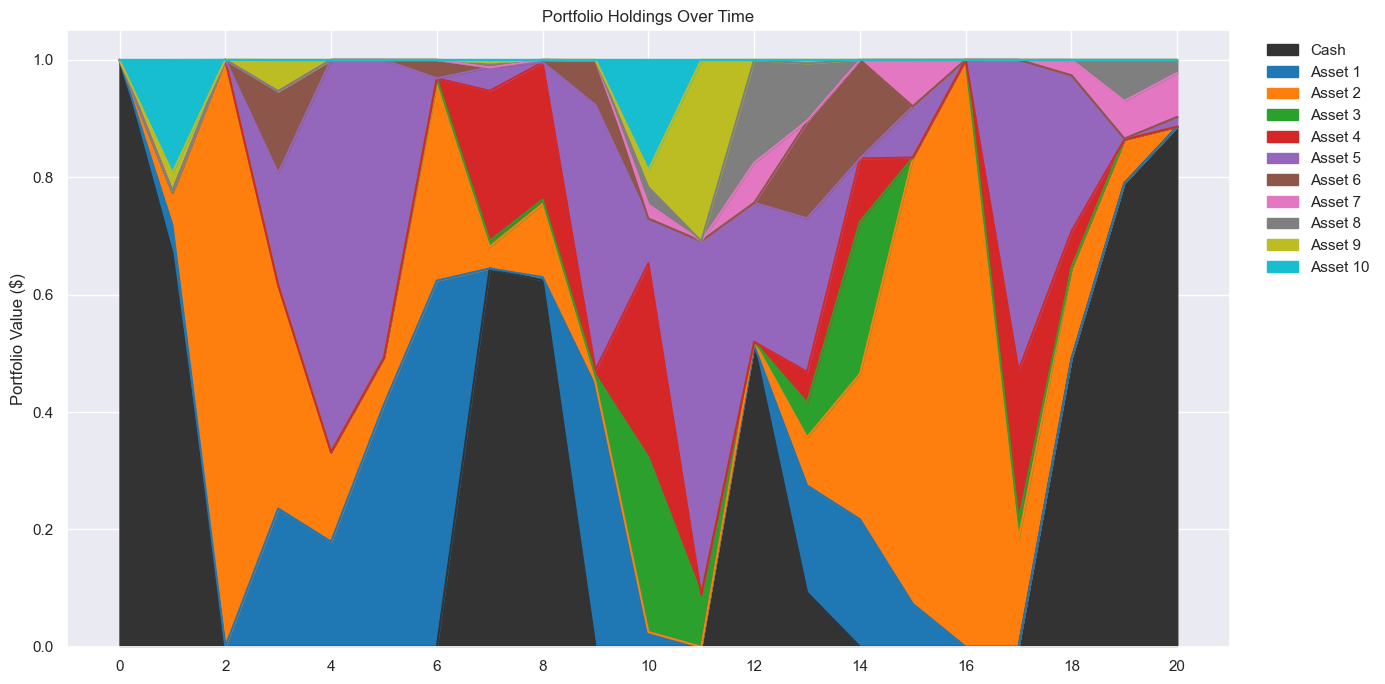

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# all except cash
asset_colors = sns.color_palette("tab10", market.n_assets)

# add cash color at the start
colors =  [(0.2, 0.2, 0.2)] + asset_colors

weights = df.div(df.sum(axis=1), axis=0)
weights[weights < 0] = 0

weights.columns = ["Cash"] + [f"Asset {i}" for i in range(1, market.n_assets+1)]

ax = weights.plot.area(
    figsize=(14, 7),
    #cmap=cmap
    color=colors
)

ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Portfolio Holdings Over Time")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

ax.set_xticks(range(0, n_steps + 1, 2))

plt.tight_layout()
#plt.savefig(project_root / "results/figures/down_portfolio_holdings.pdf")
plt.savefig(project_root / "results/figures/uptrend_portfolio_holdings.pdf")
plt.show()

In [109]:
sector_holdings = pd.DataFrame()

sector_holdings['cash'] = df[0]
df_ = df.drop(0, axis=1)

for sector in range(market.n_sectors):
    sector_holdings[sector] = df_.T.iloc[market.sectors == sector].sum(axis=0)

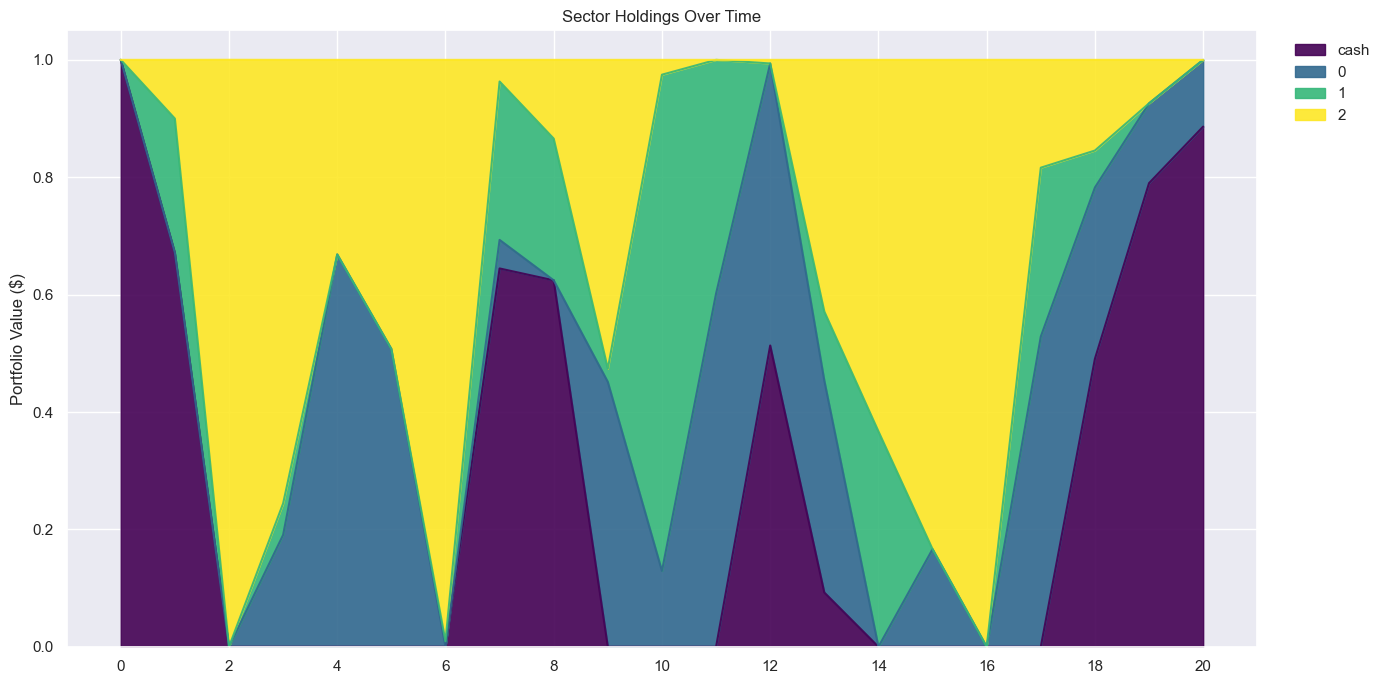

In [110]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap("viridis")

sector_weights = sector_holdings.div(df.sum(axis=1), axis=0)
sector_weights[sector_weights < 0] = 0

ax = sector_weights.plot.area(
    figsize=(14, 7),
    cmap=cmap,
    alpha=0.9
)

ax.set_ylabel("Portfolio Value ($)")
ax.set_title("Sector Holdings Over Time")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=False
)

ax.set_xticks(range(0, n_steps + 1, 2))

plt.tight_layout()
#plt.savefig(project_root / "results/figures/down_sector_holdings.pdf")
plt.savefig(project_root / "results/figures/uptrend_sector_holdings.pdf")
plt.show()

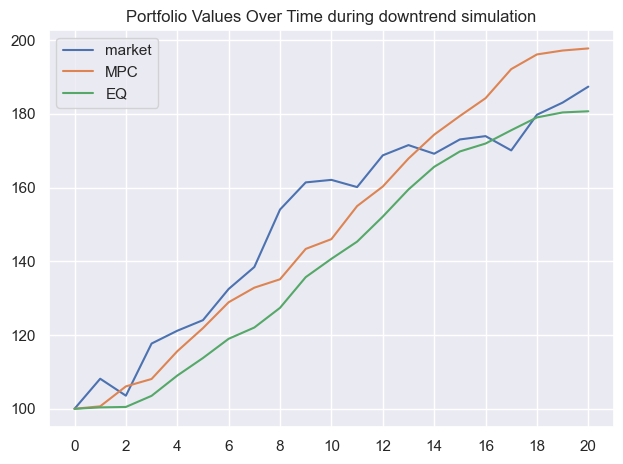

In [111]:
market_sims.iloc[sim_num].plot(label='market', legend=True)
df.sum(axis=1).plot(label='MPC', legend=True)
eq_df.sum(axis=1).plot(label='EQ', legend=True, xticks=range(0, n_steps + 1, 2), title="Portfolio Values Over Time during downtrend simulation")

plt.tight_layout()
#plt.savefig(project_root / "results/figures/down_portfolio_values.pdf")
plt.savefig(project_root / "results/figures/uptrend_portfolio_values.pdf")
plt.show()

In [112]:
market.summary()

,alpha,beta,idio vols,sector,sector_coeffs,sector_vols,vol_premium
0,0.000278,2.981126,0.010344,2,1.664776,0.008159,-4.790350
1,0.000007,2.642559,0.009399,2,1.521219,0.008159,4.108426
2,-0.000156,3.092599,0.010053,1,2.043160,0.007615,4.115642
3,0.000090,3.250551,0.010305,1,1.788262,0.007615,4.662862
4,0.000177,3.928734,0.011934,0,1.989868,0.006370,-5.415292
5,0.000013,2.949493,0.009775,2,1.615540,0.008159,-4.365453
6,0.000063,2.950060,0.009644,0,1.871046,0.006370,-3.724554
7,-0.000068,2.891410,0.009137,0,1.663281,0.006370,-3.775996
8,0.000201,2.568191,0.008571,1,1.564338,0.007615,-4.060396
9,0.000033,1.994773,0.006668,1,1.415344,0.007615,2.848176


In [113]:
w_ = weights.T.iloc[1:]

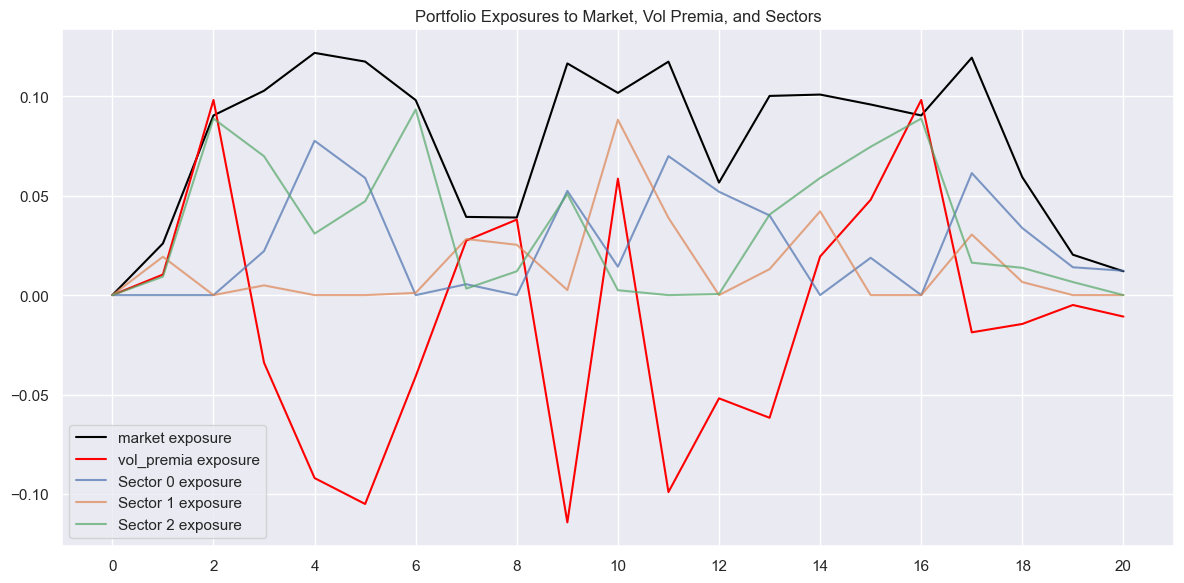

In [114]:
# Plot exposures to factors from coefficients

fig, ax = plt.subplots(1,1, figsize=(12,6))

(weights @ np.hstack([0, market.betas]) / market.betas.sum()).plot(label = 'market exposure', ax=ax, color='black')
(weights @ np.hstack([0, market.vol_premia]) / np.linalg.norm(market.vol_premia, 1)).plot(label = 'vol_premia exposure', ax=ax, color='red')

sector_exps = []
sector_scale = market.sector_coeffs.sum()

for sector in range(market.n_sectors):
    sector_mask = market.sectors == sector
    sector_exp = market.sector_coeffs[sector_mask] @ w_.iloc[sector_mask]
    sector_exps.append(sector_exp)
    (sector_exp / sector_scale).plot(label = f'Sector {sector} exposure', ax=ax, alpha=0.7)

ax.set_title("Portfolio Exposures to Market, Vol Premia, and Sectors")
ax.set_xticks(range(0, n_steps + 1, 2))
ax.legend()

fig.tight_layout()
#fig.savefig(project_root / "results/figures/down_exposures.pdf")
fig.savefig(project_root / "results/figures/up_exposures.pdf")

## Regression

In [316]:
import statsmodels.api as sm
from statsmodels.regression import linear_model

mpc_factor_model = []
mpc_params_df = pd.DataFrame()
eq_params_df = pd.DataFrame()

from src.optimized_functions import ewma_1d, ewma_2d
from src.utils import FREQ_COEFF

freq = "weekly"

dataset_path = project_root / "datasets/test"

for i, col in enumerate(returns['MPC'].columns):
    _, _, context = load_simulation(dataset_path, i)

    market_factor = ewma_1d(context['market'], 20)

    vol_factor = ewma_1d(context['market_vol'], 20)
    vol_factor = context['market_vol'] - vol_factor

    sector_factors = ewma_2d(context['sectors'], 20)

    Factors = np.concatenate([market_factor[:, None], vol_factor[:, None], sector_factors], axis=1)

    Factors = Factors[-20*FREQ_COEFF[freq]:, :]

    Factors = (1+Factors).reshape(20, FREQ_COEFF[freq], market.n_sectors + 2).prod(axis=1)

    Factors = pd.DataFrame(Factors, index=returns['MPC'][col].index)
    Factors.columns = ['Market', 'vol_premia'] + [f"sector {j}" for j in range(market.n_sectors)]

    lm = linear_model.OLS(np.log(1+returns['MPC'][col]), sm.add_constant(Factors)).fit()
    mpc_factor_model.append(lm)

    mpc_params_df[i] = lm.params

    lm = linear_model.OLS(np.log(1+returns['EQ'][col]), sm.add_constant(Factors)).fit()

    eq_params_df[i] = lm.params

In [323]:
mpc_params_df_without_insig = pd.DataFrame()
for i, lm in enumerate(mpc_factor_model):    
    params = lm.params.copy()
    params[lm.pvalues > 0.05] = 0
    mpc_params_df_without_insig[i] = params   

In [324]:
mpc_params_df_without_insig.index = mpc_params_df.index

(-10.0, 10.0)

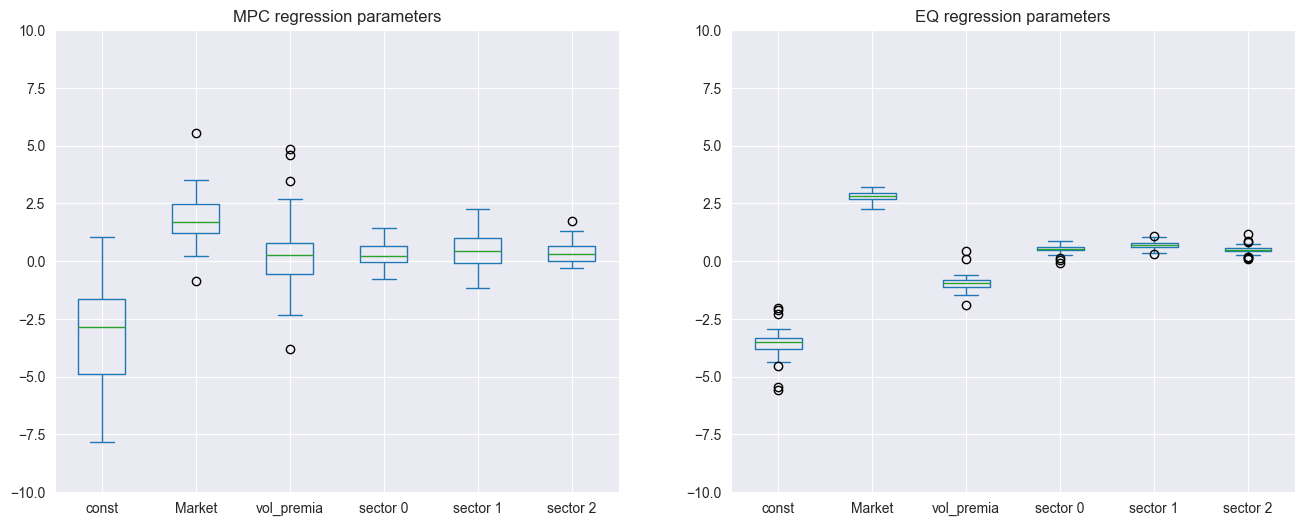

In [332]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

mpc_params_df.T.plot(kind='box', ax=ax[0])
eq_params_df.T.plot(kind='box', ax=ax[1])

ax[0].set_title('MPC regression parameters')
ax[1].set_title('EQ regression parameters')

ax[0].set_ylim(-10, 10)
ax[1].set_ylim(-10, 10)

## Misspecification

In [115]:
MPC_miss = {0.0 : MPC_sims}
MPC_miss_full = {0.0 : MPC_sims_full}

for miss_alpha in [0.05, 0.1, 0.2, 0.3]:
    str_index = str(miss_alpha).replace('.', '')

    MPC_miss_full[miss_alpha] = load(save_path / f"{config['name']}_misspec{str_index}_sims.joblib")
    MPC_miss[miss_alpha] = pd.DataFrame(MPC_miss_full[miss_alpha].sum(axis=2))

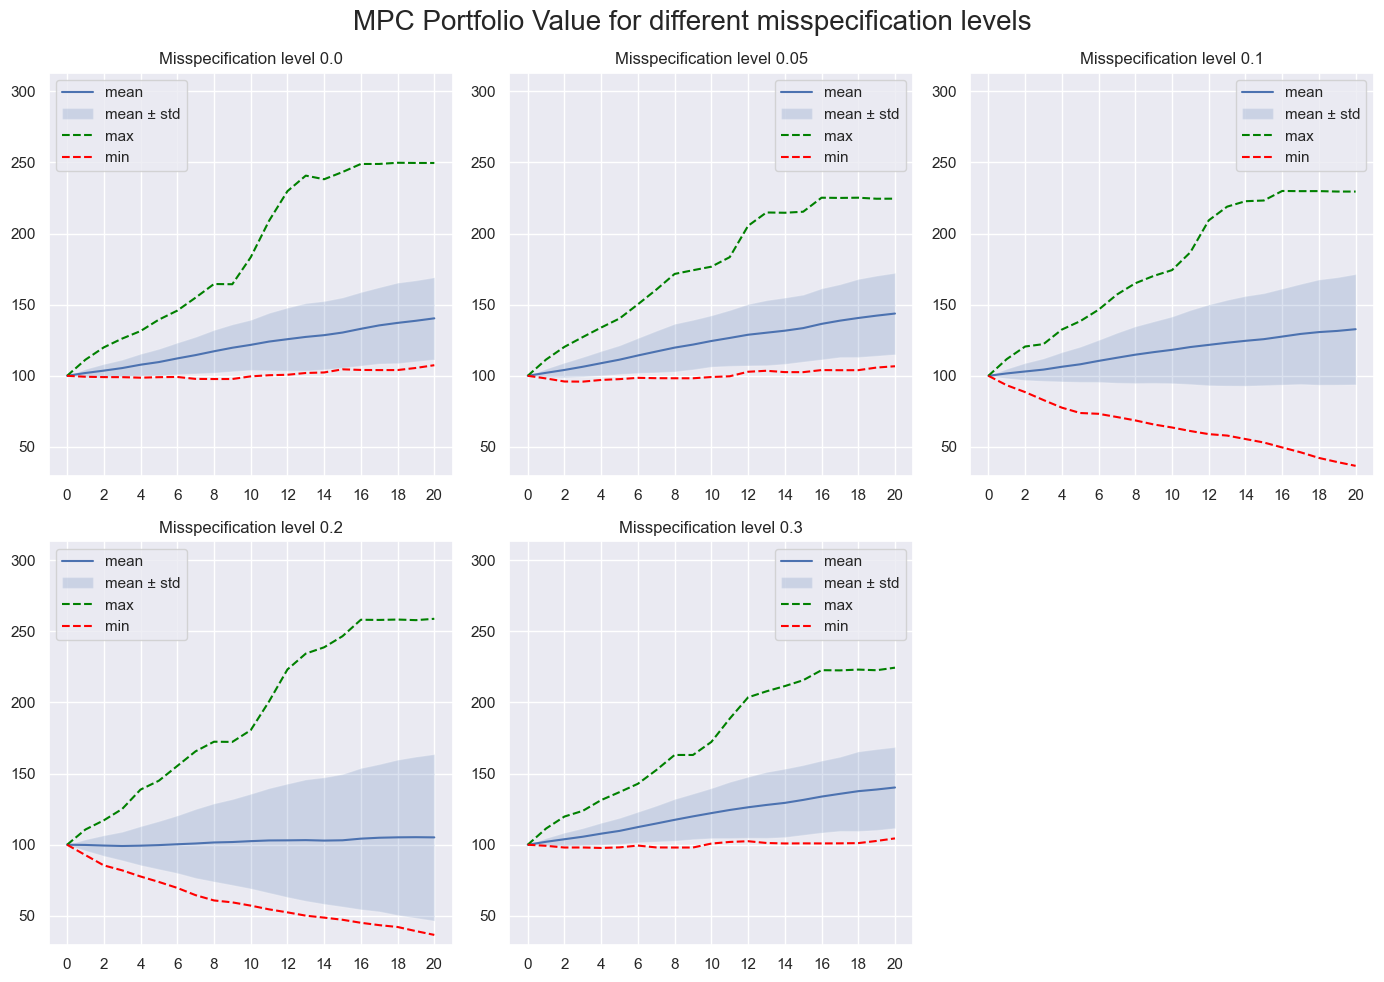

In [132]:
fig, ax = plt.subplots(2,3, figsize=(14,10))

fig.suptitle("MPC Portfolio Value for different misspecification levels", fontsize=20)

for aa in ax.flatten():
    aa.set_xticks(range(0, n_steps + 1, 2))


plot_simulations([MPC for MPC in MPC_miss.values()], labels=[f"Misspecification level {a}" for a in MPC_miss.keys()], ax=ax)

fig.tight_layout()
fig.savefig(project_root / "results/figures/misspecification_mpc.pdf")

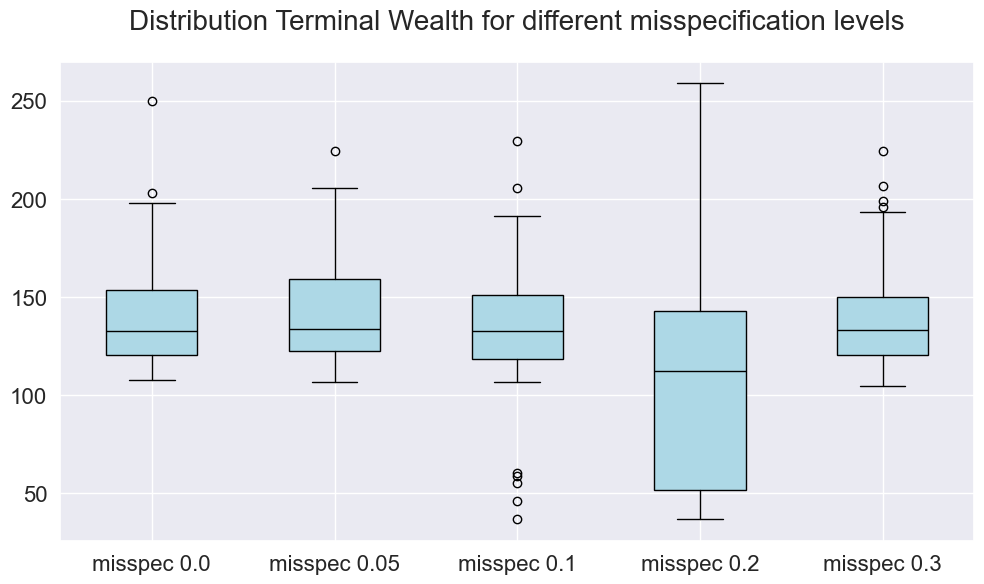

In [117]:
fig, ax = plt.subplots(1,1, figsize=(10,6))

ax.boxplot([MPC_miss[miss_alpha][20] for miss_alpha in MPC_miss], tick_labels=[f"misspec {a}" for a in MPC_miss.keys()],
           patch_artist=True, boxprops=dict(facecolor='lightblue', color='black'),
           medianprops=dict(color='black'))

ax.set_title("Distribution Terminal Wealth for different misspecification levels", fontsize=20, y=1.05)
ax.tick_params(axis='both', which='major', labelsize=16)

fig.tight_layout()
fig.savefig(project_root / "results/figures/misspecification_mpc_boxplot.pdf")

In [133]:
miss_ret = compute_returns([MPC_miss[miss_alpha] for miss_alpha in MPC_miss], names=[f"misspec {a}" for a in MPC_miss.keys()])

In [147]:
exceedance_rates = [(miss_ret[key] < -0.01).sum().sum() for key in miss_ret]

eq_exceedance_rate = (returns['EQ'] < -0.01).sum().sum()

exceedance_rates = [eq_exceedance_rate] + exceedance_rates

exceedance_df = pd.DataFrame(exceedance_rates, index=['EQ'] + list(miss_ret.keys()), columns=['Number of Exceedances'])

In [149]:
key = list(miss_ret.keys())[0]
exceedance_df["in %"] = exceedance_df['Number of Exceedances'] / (miss_ret[key].shape[0] * miss_ret[key].shape[1]) * 100

latex_table = exceedance_df.to_latex(
    index=True,  # To not include the DataFrame index as a column in the table
    caption="Exceedance Rates of -0.01 (with EQ as a reference)",  # The caption to appear above the table in the LaTeX document
    label="tab:Exceedance_Rates",  # A label used for referencing the table within the LaTeX document
    position="htbp",  # The preferred positions where the table should be placed in the document ('here', 'top', 'bottom', 'page')
    column_format="lcc",  # The format of the columns: left-aligend first column and center-aligned remaining columns as per APA guidelines
    escape=True,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.1f}".format  # Formats floats to two decimal places
)

print(latex_table)

\begin{table}[htbp]
\caption{Exceedance Rates of -0.01 (with EQ as a reference)}
\label{tab:Exceedance_Rates}
\begin{tabular}{lcc}
\toprule
 & Number of Exceedances & in \% \\
\midrule
EQ & 322 & 32.2 \\
misspec 0.0 & 22 & 2.2 \\
misspec 0.05 & 34 & 3.4 \\
misspec 0.1 & 98 & 9.8 \\
misspec 0.2 & 417 & 41.7 \\
misspec 0.3 & 32 & 3.2 \\
\bottomrule
\end{tabular}
\end{table}



In [121]:
metrics = compute_metrics(miss_ret, rf)
metrics = multi_level_metric(metrics)

In [122]:
def specific_plot(metrics):

    # --------------------------------------------------
    # Metrics to plot
    # --------------------------------------------------

    metrics_to_plot = [
        "mean returns",
        "sharpe ratios",
        "sortino ratios",
        "max drawdowns",
        "95% VaR",
        "95% CVaR"
    ]

    titles = [
        "Mean Returns",
        "Sharpe Ratio",
        "Sortino Ratio",
        "Max Drawdown",
        "95% Value at Risk",
        "95% Conditional Value at Risk"
    ]

    # --------------------------------------------------
    # Create subplot grid
    # --------------------------------------------------

    fig, axes = plt.subplots(
        3, 2,
        figsize=(14, 15),
        constrained_layout=True
    )

    axes = axes.flatten()

    x_vals = [
        float(col.replace("misspec ", ""))
        for col in metrics.columns
    ]

    # --------------------------------------------------
    # Plot each metric
    # --------------------------------------------------

    for ax, metric, title in zip(axes, metrics_to_plot, titles):

        # Extract rows for this metric
        metric_df = metrics.loc[metric]

        # Main line
        mean_vals = metric_df.loc["mean"].values

        # Confidence interval
        ci_low = metric_df.loc["ci_low"].values
        ci_high = metric_df.loc["ci_high"].values

        # Plot mean line
        ax.plot(
            x_vals,
            mean_vals,
            marker="o",
            linewidth=2.5,
            color="#1f77b4"
        )

        # Confidence ribbon
        ax.fill_between(
            x_vals,
            ci_low,
            ci_high,
            alpha=0.25,
            color="#1f77b4"
        )

        # Formatting
        ax.set_title(title, fontsize=16, weight="bold")
        ax.set_xlabel("Misspecification")
        ax.set_ylabel("Value")

        # Zero line for intuition
        ax.axhline(
            0,
            linestyle="--",
            linewidth=1,
            color="black",
            alpha=0.5
        )

    # --------------------------------------------------
    # Main title
    # --------------------------------------------------

    fig.suptitle(
        "Portfolio Performance Under Model Misspecification",
        fontsize=20,
        weight="bold"
    )

    plt.show()
    fig.savefig(project_root / "results/figures/misspecification_metrics.pdf")

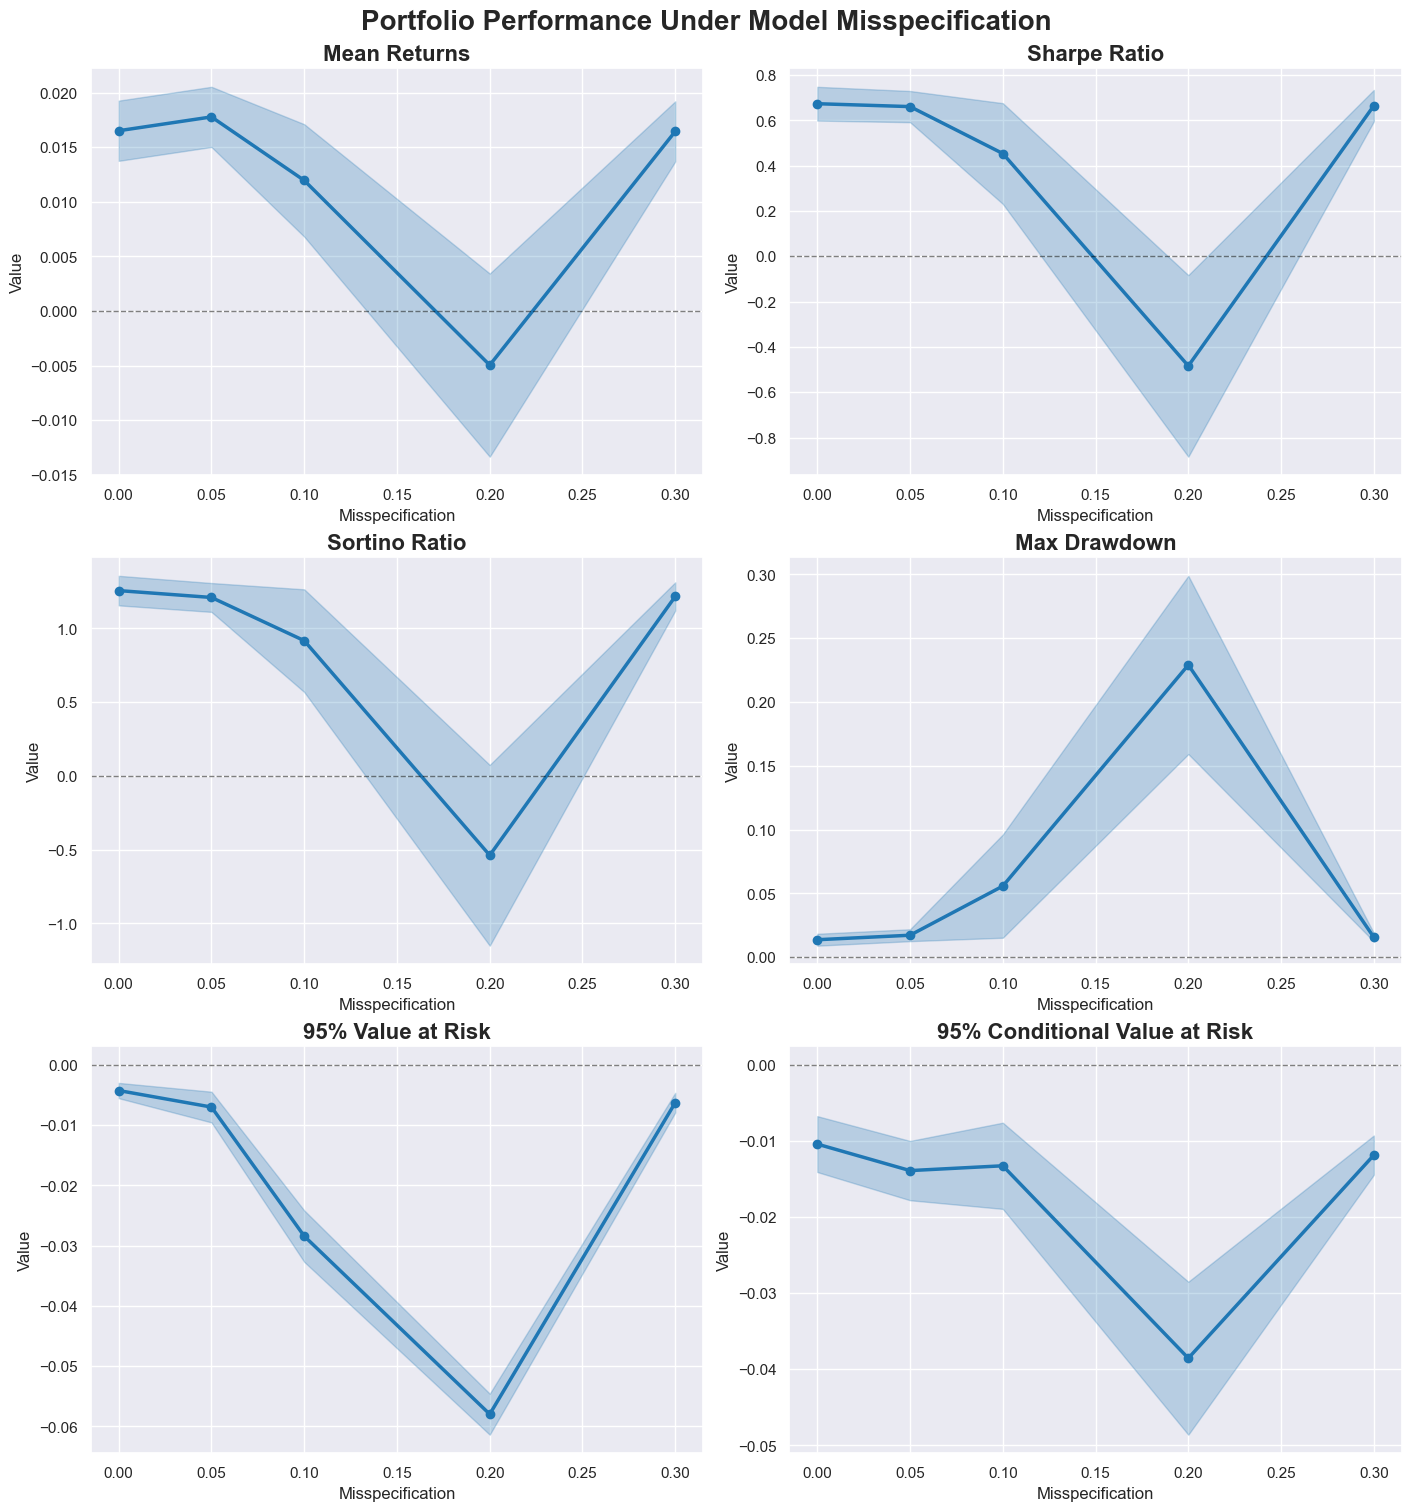

In [123]:
specific_plot(metrics)